In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [21]:
from sklearn.datasets import load_iris
iris=load_iris()

In [22]:
iris
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

# DIVISION OF DEPENDENT AND INDEPENDENT DATA 

In [23]:
print(iris['target'])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [24]:
x=pd.DataFrame(iris['data'],columns=['sepal length in cm','sepal width in cm','petal length in cm','petal width' ])

In [ ]:
y=iris['target']
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)    

# IMPLEMENTIGN DECISION TREE CLASSIFIER

# also realizing the need of post prunning

In [26]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier(max_depth=2)
dtc.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.4, 0.8333333333333334, 'x[2] <= 2.45\ngini = 0.667\nsamples = 120\nvalue = [40, 41, 39]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 40\nvalue = [40, 0, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[2] <= 4.75\ngini = 0.5\nsamples = 80\nvalue = [0, 41, 39]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.053\nsamples = 37\nvalue = [0, 36, 1]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.206\nsamples = 43\nvalue = [0, 5, 38]')]

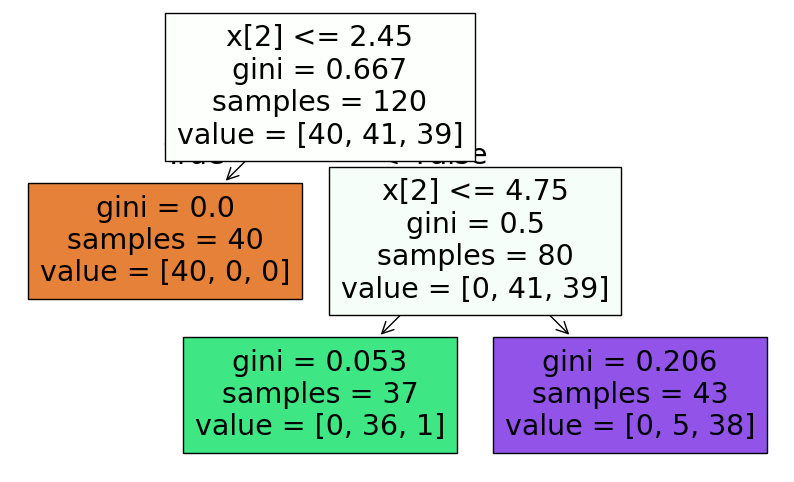

In [27]:
# visualize the decision tree
from sklearn import tree
plt.figure(figsize=(10,6))
tree.plot_tree(dtc,filled=True)

In [31]:
y_pred=dtc.predict(x_test)

In [33]:
#no need to split after level 2 kyuki data is very less and simple mtlb ek type ka data hi max h to answer vahi ayega
#hereby we can do postpruning by setting max_depth parameter while creating decision tree classifier object
# hence we set in decision tree max_depth=2


from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(f"accuracy score is {accuracy_score(y_test,y_pred)}")
print(f"confusion matrix is {confusion_matrix(y_test,y_pred)}")
print(f"classification report is {classification_report(y_test,y_pred)}")





accuracy score is 0.9666666666666667
confusion matrix is [[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]
classification report is               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



# DECISION TREE HYPERPARAMETER TUNING AND PREPRUNING

In [ ]:
# WE USE POST PRUNNING ONLY FOR SMALLER DATASETS FOR BIIGER ONES WE APPLY PRE PRUNNING
# PRE PRUNNING MEANS HUM TREE BANATE TIME HI USME RESTRICTIONS LAGATE HAI JISE MAX_DEPTH ETC ETC
# POST PRUNNING MEANS HUM PURE TREE BANATE HAI USKE BAAD USME SE RESTRICTIONS LAGATE HAI

param={
    'criterion':['gini','entropy','log loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,6,7,8,9],
    'max_features':['auto','sqrt','log2']

}

In [39]:
from sklearn.model_selection import GridSearchCV
gscv=GridSearchCV(estimator=dtc,param_grid=param,cv=5,n_jobs=-1)
gscv.fit(x_train,y_train)
print(f"best parameters are {gscv.best_params_}")

best parameters are {'criterion': 'entropy', 'max_depth': 2, 'max_features': 'log2', 'splitter': 'best'}


/Users/yashkumar/Desktop/ai ml code/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
450 fits failed out of a total of 810.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/yashkumar/Desktop/ai ml code/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/yashkumar/Desktop/ai ml code/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1356, in wrapper
    estimator._validate_params()
  File "/Users/yashkumar/Desktop/ai ml code/.venv/lib/python3.12/site-packages/sklearn/base.py", lin

In [41]:
gscv.best_params_

{'criterion': 'entropy',
 'max_depth': 2,
 'max_features': 'log2',
 'splitter': 'best'}

In [43]:
gscv.best_score_

np.float64(0.9583333333333334)

In [44]:
g_y_pred=gscv.predict(x_test)
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
print(f"accuracy score is {accuracy_score(y_test,g_y_pred)}")
print(f"confusion matrix is {confusion_matrix(y_test,g_y_pred)}")
print(f"classification report is {classification_report(y_test,g_y_pred)}")

accuracy score is 0.9666666666666667
confusion matrix is [[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]
classification report is               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30

